In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from torchvision import transforms
%matplotlib inline
torch.manual_seed(1)

In [35]:
# Confirm builds before running dataset and transform code
print("torch:", torch.__version__)
print("numpy:", np.__version__)

torch: 2.12.0+cpu
numpy: 2.2.6


In [36]:
print(torch.ones(10, 2))
print(torch.ones(10, 1))
print(torch.ones(10, 3))

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])


In [37]:
# Subclass Dataset and implement __len__ + __getitem__ — PyTorch's DataLoader requires both
# __init__ stores data and an optional transform; __getitem__ applies the transform lazily per sample
class ToySet(Dataset):

    def __init__(self, length=100, transform=None):
        self.len = length
        # torch.ones(d0, d1, ...) returns a float tensor of shape (d0, d1, ...) filled with 1.0
        # x is (length, 2) — two features per sample; y is (length, 1) — one label per sample
        self.x = 2 * torch.ones(length, 2)
        self.y = torch.ones(length, 1)
        self.transform = transform

    def __getitem__(self, index):
        sample = self.x[index], self.y[index]
        # Transform is applied here (at read time), not at construction — keeps raw data intact
        if self.transform:
            sample = self.transform(sample)
        return sample

    def __len__(self):
        return self.len

In [38]:
# Dataset supports len() and [] because __len__ and __getitem__ are defined
dataset = ToySet()
print("dataset object:", dataset)
print("length:", len(dataset))
print("sample at index 0:", dataset[0])

dataset object: <__main__.ToySet object at 0x79375860c970>
length: 100
sample at index 0: (tensor([2., 2.]), tensor([1.]))


In [39]:
# Index-based access — equivalent to calling __getitem__ directly
for i in range(3):
    x, y = dataset[i]
    print(f"index {i}  x: {x}  y: {y}")

index 0  x: tensor([2., 2.])  y: tensor([1.])
index 1  x: tensor([2., 2.])  y: tensor([1.])
index 2  x: tensor([2., 2.])  y: tensor([1.])


In [40]:
# Dataset is iterable because __getitem__ + __len__ satisfy Python's iterator protocol
# This is the same mechanism DataLoader uses internally
for x, y in ToySet(length=3):
    print(f"x: {x}  y: {y}")

x: tensor([2., 2.])  y: tensor([1.])
x: tensor([2., 2.])  y: tensor([1.])
x: tensor([2., 2.])  y: tensor([1.])


In [41]:
# A transform is any callable that accepts a (x, y) tuple and returns a modified (x, y) tuple
# __call__ makes an instance behave like a function, so it can be passed as transform=
class AddMultiply(object):

    def __init__(self, addx=1, muly=2):
        self.addx = addx
        self.muly = muly

    def __call__(self, sample):
        x, y = sample
        return x + self.addx, y * self.muly

In [42]:
# Apply transform manually to verify it: x=[2,2]+1=[3,3], y=[1]*2=[2]
a_m = AddMultiply()
raw_dataset = ToySet()

for i in range(3):
    x, y = raw_dataset[i]
    x_, y_ = a_m(raw_dataset[i])
    print(f"index {i}  original x: {x} y: {y}  →  transformed x: {x_} y: {y_}")

index 0  original x: tensor([2., 2.]) y: tensor([1.])  →  transformed x: tensor([3., 3.]) y: tensor([2.])
index 1  original x: tensor([2., 2.]) y: tensor([1.])  →  transformed x: tensor([3., 3.]) y: tensor([2.])
index 2  original x: tensor([2., 2.]) y: tensor([1.])  →  transformed x: tensor([3., 3.]) y: tensor([2.])


In [43]:
# Passing transform= at construction bakes it into every __getitem__ call automatically
# The raw tensors in self.x / self.y are unchanged — transform runs on the fly each read
transformed_dataset = ToySet(transform=a_m)

for i in range(3):
    x_raw, y_raw = raw_dataset[i]
    x_tf, y_tf = transformed_dataset[i]
    print(f"index {i}  raw: x={x_raw} y={y_raw}  →  transformed: x={x_tf} y={y_tf}")

index 0  raw: x=tensor([2., 2.]) y=tensor([1.])  →  transformed: x=tensor([3., 3.]) y=tensor([2.])
index 1  raw: x=tensor([2., 2.]) y=tensor([1.])  →  transformed: x=tensor([3., 3.]) y=tensor([2.])
index 2  raw: x=tensor([2., 2.]) y=tensor([1.])  →  transformed: x=tensor([3., 3.]) y=tensor([2.])


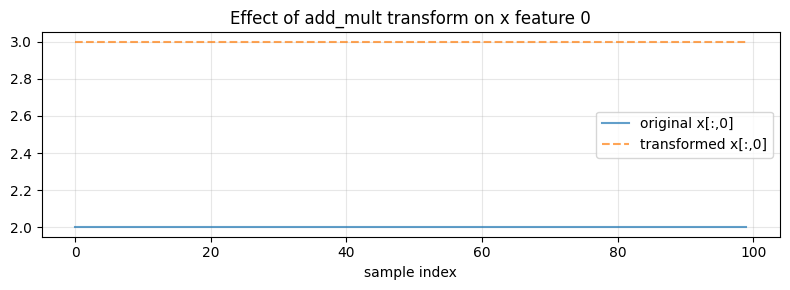

In [44]:
# Visualise the shift: original x[:,0] vs transformed x[:,0] across the full dataset
raw_x0   = [raw_dataset[i][0][0].item()         for i in range(len(raw_dataset))]
trans_x0 = [transformed_dataset[i][0][0].item() for i in range(len(transformed_dataset))]

plt.figure(figsize=(8, 3))
plt.plot(raw_x0,   label="original x[:,0]",     alpha=0.7)
plt.plot(trans_x0, label="transformed x[:,0]",  alpha=0.7, linestyle="--")
plt.title("Effect of add_mult transform on x feature 0")
plt.xlabel("sample index")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
# Second transform: scale both x and y by a constant
# Defining it separately allows independent use and composition in any order
class Multiply(object):

    def __init__(self, factor=100):
        self.factor = factor

    def __call__(self, sample):
        x, y = sample
        return x * self.factor, y * self.factor

In [46]:
# transforms.Compose chains callables left-to-right: output of step N is input to step N+1
# AddMultiply first (x+1, y*2), then Multiply (x*100, y*100)
# expected for default values: x = (2+1)*100 = 300, y = (1*2)*100 = 200
data_transform = transforms.Compose([AddMultiply(), Multiply()])
print("Compose pipeline:", data_transform)

Compose pipeline: Compose(
)


In [47]:
# Verify a single sample manually before wiring it into the dataset
x_raw, y_raw = raw_dataset[0]
x_comp, y_comp = data_transform(raw_dataset[0])
print(f"raw:      x={x_raw} y={y_raw}")
print(f"composed: x={x_comp} y={y_comp}")

raw:      x=tensor([2., 2.]) y=tensor([1.])
composed: x=tensor([300., 300.]) y=tensor([200.])


In [48]:
# Wire the full Compose pipeline into a dataset — same pattern as a single transform
composed_dataset = ToySet(transform=data_transform)

for i in range(3):
    x,    y    = raw_dataset[i]
    x_tf, y_tf = transformed_dataset[i]
    x_co, y_co = composed_dataset[i]
    print(f"index {i}")
    print(f"  raw:         x={x} y={y}")
    print(f"  AddMultiply: x={x_tf} y={y_tf}")
    print(f"  composed:    x={x_co} y={y_co}")

index 0
  raw:         x=tensor([2., 2.]) y=tensor([1.])
  AddMultiply: x=tensor([3., 3.]) y=tensor([2.])
  composed:    x=tensor([300., 300.]) y=tensor([200.])
index 1
  raw:         x=tensor([2., 2.]) y=tensor([1.])
  AddMultiply: x=tensor([3., 3.]) y=tensor([2.])
  composed:    x=tensor([300., 300.]) y=tensor([200.])
index 2
  raw:         x=tensor([2., 2.]) y=tensor([1.])
  AddMultiply: x=tensor([3., 3.]) y=tensor([2.])
  composed:    x=tensor([300., 300.]) y=tensor([200.])


In [49]:
# Compose order is NOT commutative — swapping transforms gives different results
# Multiply first: x=(2*100)+1=201, y=(1*100)*2=200
# AddMultiply first: x=(2+1)*100=300, y=(1*2)*100=200
reversed_transform = transforms.Compose([Multiply(), AddMultiply()])
reversed_dataset   = ToySet(transform=reversed_transform)

x_am,  y_am  = composed_dataset[0]   # AddMultiply → Multiply
x_rev, y_rev = reversed_dataset[0]    # Multiply → AddMultiply
print(f"AddMultiply → Multiply:  x={x_am}  y={y_am}")
print(f"Multiply → AddMultiply:  x={x_rev} y={y_rev}")

AddMultiply → Multiply:  x=tensor([300., 300.])  y=tensor([200.])
Multiply → AddMultiply:  x=tensor([201., 201.]) y=tensor([200.])


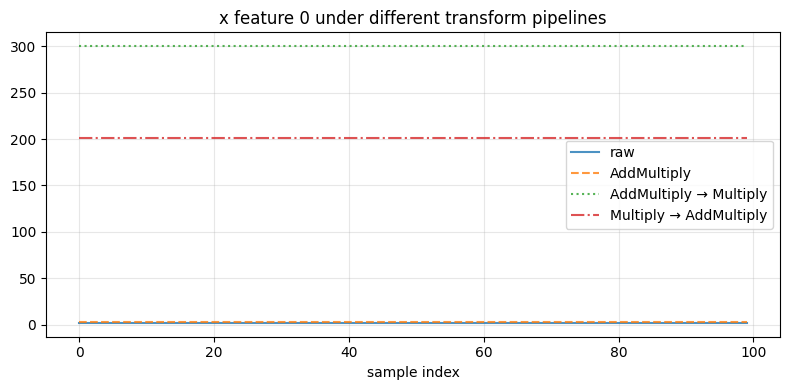

In [50]:
# Compare x feature 0 across all four variants to visualise pipeline differences
indices = range(len(raw_dataset))

raw_vals      = [raw_dataset[i][0][0].item()         for i in indices]
addmul_vals   = [transformed_dataset[i][0][0].item() for i in indices]
composed_vals = [composed_dataset[i][0][0].item()    for i in indices]
reversed_vals = [reversed_dataset[i][0][0].item()    for i in indices]

plt.figure(figsize=(8, 4))
plt.plot(raw_vals,      label="raw",                       alpha=0.8)
plt.plot(addmul_vals,   label="AddMultiply",               alpha=0.8, linestyle="--")
plt.plot(composed_vals, label="AddMultiply → Multiply",    alpha=0.8, linestyle=":")
plt.plot(reversed_vals, label="Multiply → AddMultiply",    alpha=0.8, linestyle="-.")
plt.title("x feature 0 under different transform pipelines")
plt.xlabel("sample index")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()